**Code des solutions** **Optimisé**

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 68.9 MB/s eta 0:00:00


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.0MB/s]


Utilisation du device: cuda

=== Expérience 1: Disparition du Gradient et Solutions (2.2) ===
--- Problème: Réseau profond avec Sigmoïde ---
--- Solution 2.2.1: Initialisation de Xavier ---
--- Solution 2.2.2: Batch Normalization ---
--- Solution 2.2.3: Connexions Résiduelles ---


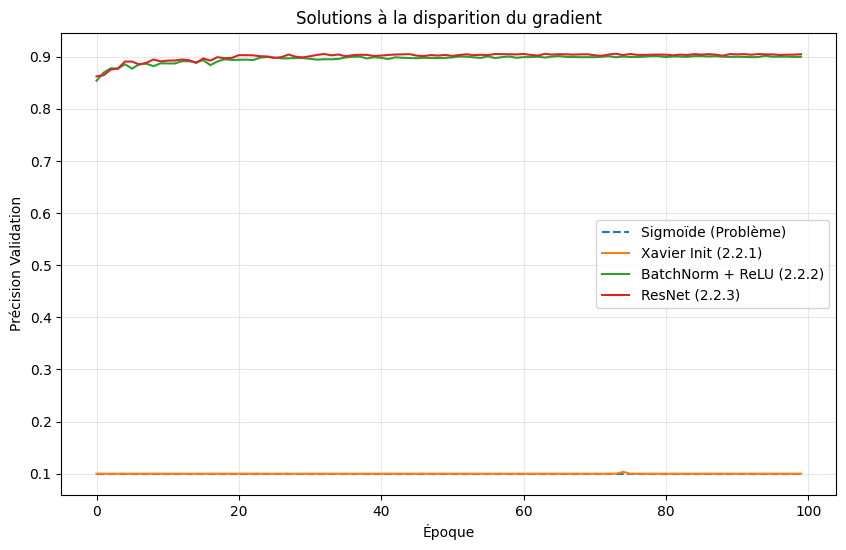


=== Expérience 2: Surapprentissage et Solutions (2.1) ===
--- Problème: Réseau large sur petit dataset ---
--- Solution 2.1.2: Régularisation L2 (Ridge) ---
--- Solution 2.1.3: Régularisation L1 (Lasso) ---
--- Solution 2.1.4: Dropout ---


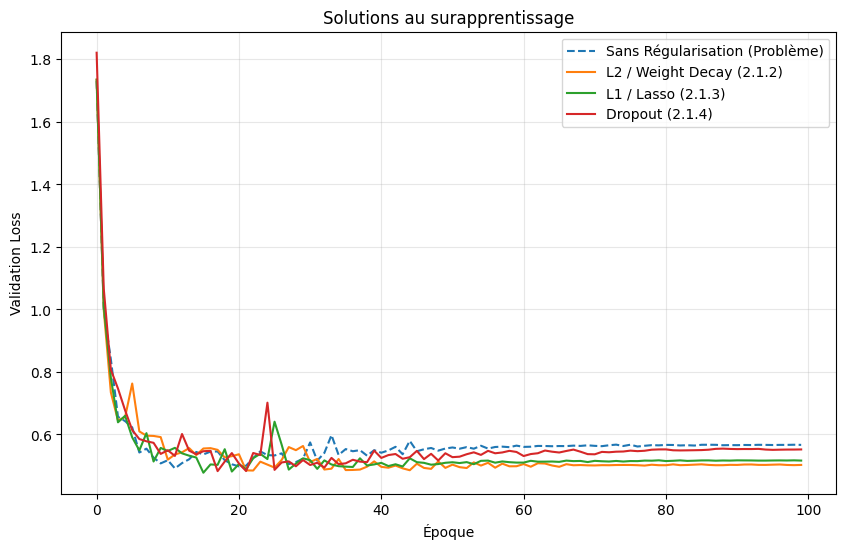


=== Expérience 3: Optimisation Non Convexe et Solutions (2.3) ===
--- Problème: SGD avec différentes initialisations ---
SGD Précisions finales: ['0.9025', '0.9026', '0.9003'], Variance: 0.000001
--- Solution 2.3.2: Optimiseur Adam ---
Adam Précisions finales: ['0.9002', '0.9007', '0.8991'], Variance: 0.000000
--- Solution 2.3.3: LBFGS (Méthode de Newton tronquée) ---
LBFGS Précisions finales (sur 500 imgs): ['0.8150', '0.1000', '0.1000'], Variance: 0.113606
Observation: Adam réduit la variance et converge mieux que SGD. LBFGS (quasi-Newton) est très stable mais nécessite beaucoup de mémoire.


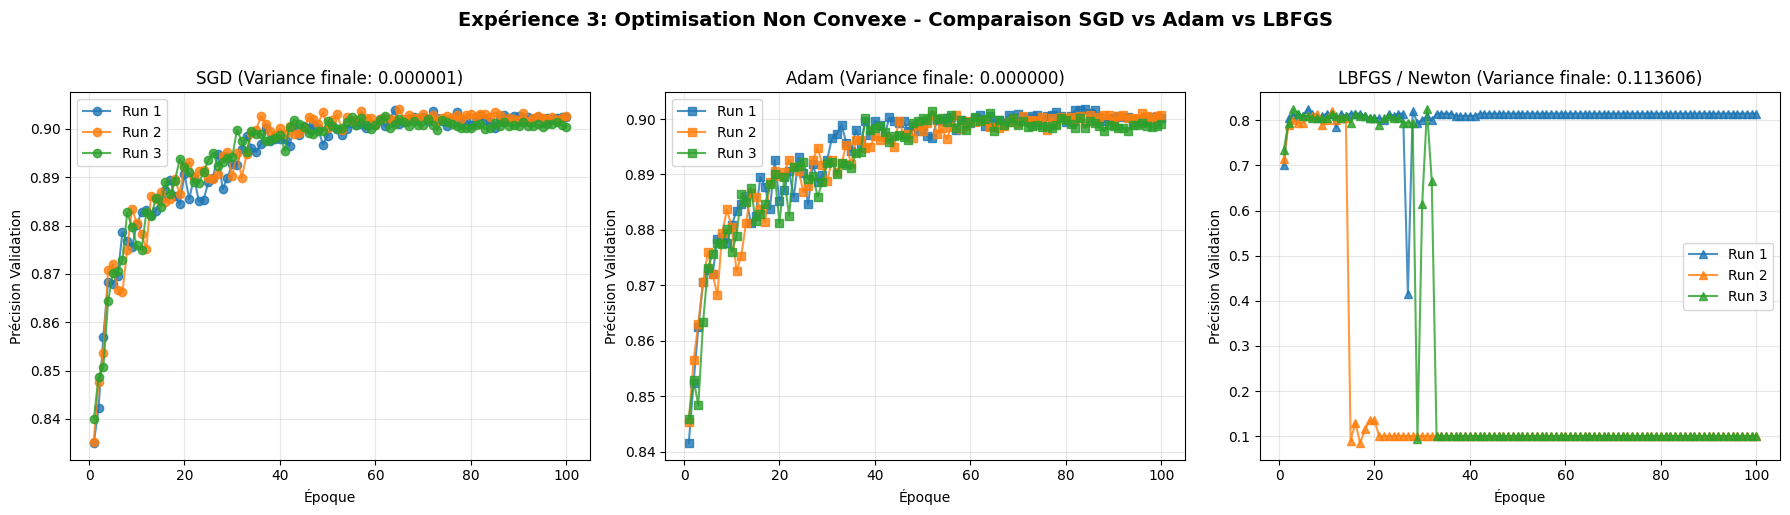

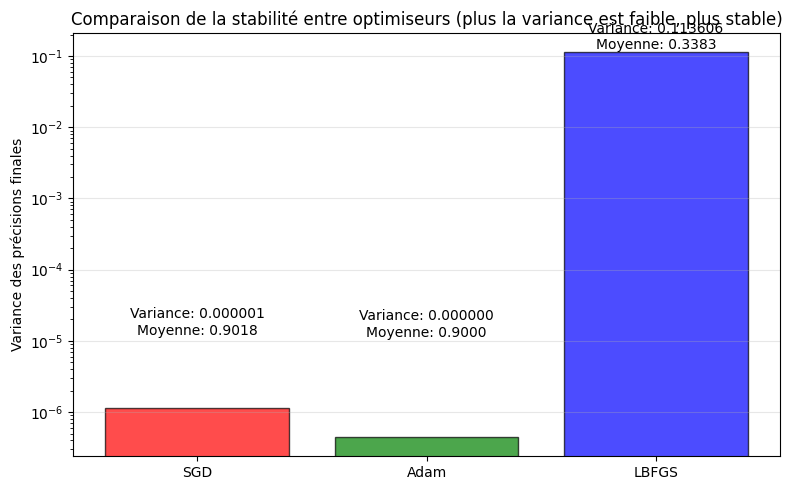


=== Expérience 4: Covariate Shift et Solution (2.4) ===
--- Problème: Baisse de performance sur distribution décalée ---
Précision sans solution sur test bruité: 0.8772
--- Solution 2.4.2: Rééchantillonnage par Importance (Discriminateur) ---
Précision avec Importance Weighting sur test bruité: 0.8762


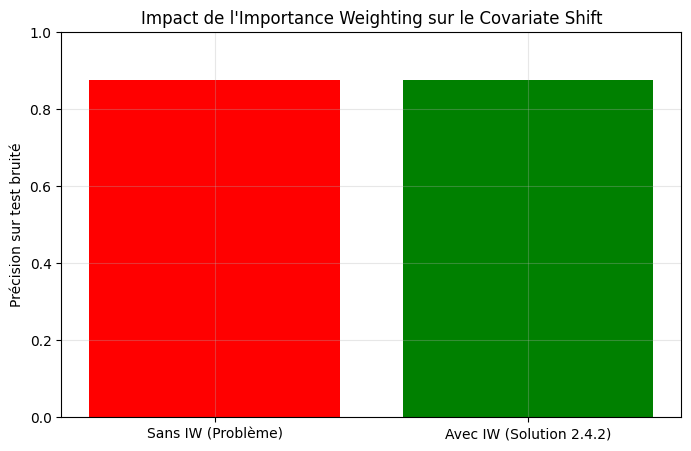

In [1]:
# Désinstaller la version incompatible
!pip uninstall sympy -y
# Installer la version compatible avec PyTorch 2.11.0
!pip install sympy==1.13.3

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Pour la reproductibilité
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# ==============================================================================
# 1. Préparation du dataset Fashion-MNIST
# ==============================================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

small_train_dataset = Subset(train_dataset, indices=list(range(1000)))
small_val_dataset = Subset(test_dataset, indices=list(range(200)))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
small_train_loader = DataLoader(small_train_dataset, batch_size=64, shuffle=True)
small_val_loader = DataLoader(small_val_dataset, batch_size=64, shuffle=False)

# ==============================================================================
# 2. Définition des Modèles
# ==============================================================================

class VanishingGradientNet(nn.Module):
    def __init__(self, n_layers=8, hidden_size=256, use_xavier=False):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(28*28, hidden_size), nn.Sigmoid()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_size, hidden_size), nn.Sigmoid()])
        layers.append(nn.Linear(hidden_size, 10))
        self.net = nn.Sequential(*layers)
        if use_xavier:
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight)
    def forward(self, x): return self.net(x)

class DeepNetWithBN(nn.Module):
    def __init__(self, n_layers=8, hidden_size=256):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(28*28, hidden_size), nn.BatchNorm1d(hidden_size), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_size, hidden_size), nn.BatchNorm1d(hidden_size), nn.ReLU()])
        layers.append(nn.Linear(hidden_size, 10))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.fc2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features), nn.BatchNorm1d(out_features)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.fc1(x)))
        out = self.bn2(self.fc2(out))
        out += self.shortcut(x)
        return F.relu(out)

class ResidualNet(nn.Module):
    def __init__(self, n_blocks=4, hidden_size=256):
        super().__init__()
        self.flatten = nn.Flatten()
        self.initial = nn.Sequential(nn.Linear(28*28, hidden_size), nn.BatchNorm1d(hidden_size), nn.ReLU())
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_size, hidden_size) for _ in range(n_blocks)])
        self.fc_out = nn.Linear(hidden_size, 10)
    def forward(self, x):
        x = self.flatten(x)
        x = self.initial(x)
        x = self.blocks(x)
        return self.fc_out(x)

class OverfittingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(28*28, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(), nn.Linear(1024, 10)
        )
    def forward(self, x): return self.net(x)

class OverfittingNetWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)
        self.dropout = nn.Dropout(0.5)
    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        return self.fc3(x)

class BaselineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(28*28, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(28*28, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, x): return self.net(x)

# ==============================================================================
# 3. Utilitaires d'Entraînement (avec plus d'époques et scheduler)
# ==============================================================================
def train_and_evaluate(model, train_loader, val_loader, epochs=100, lr=0.01, momentum=0.9,
                       weight_decay=0.0, l1_penalty=0.0, optimizer_type='sgd', device='cpu', verbose=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss(reduction='none')

    if optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    elif optimizer_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == 'lbfgs':
        optimizer = optim.LBFGS(model.parameters(), lr=lr, max_iter=20)

    # Correction : suppression de l'argument verbose
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            if len(batch) == 3:
                images, labels, weights = batch
                weights = weights.to(device)
            else:
                images, labels = batch
                weights = None

            images, labels = images.to(device), labels.to(device)

            if optimizer_type == 'lbfgs':
                def closure():
                    optimizer.zero_grad()
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss = (loss * weights).mean() if weights is not None else loss.mean()
                    if l1_penalty > 0:
                        l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
                        loss += l1_penalty * l1_reg
                    loss.backward()
                    return loss
                loss_val = optimizer.step(closure)
                total_loss += loss_val if loss_val is not None else closure().item()
            else:
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss = (loss * weights).mean() if weights is not None else loss.mean()
                if l1_penalty > 0:
                    l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
                    loss += l1_penalty * l1_reg
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).mean().item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_loss_avg = val_loss / len(val_loader)
        val_losses.append(val_loss_avg)
        val_accuracies.append(correct / total)

        # Mise à jour du scheduler
        scheduler.step(val_loss_avg)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

    return train_losses, val_losses, val_accuracies

# ==============================================================================
# 4. Expériences
# ==============================================================================

def experiment_vanishing_gradient_and_solutions(device='cpu'):
    print("\n=== Expérience 1: Disparition du Gradient et Solutions (2.2) ===")

    print("--- Problème: Réseau profond avec Sigmoïde ---")
    model_base = VanishingGradientNet(n_layers=8, hidden_size=256, use_xavier=False)
    _, _, accs_base = train_and_evaluate(model_base, train_loader, test_loader, epochs=100, device=device, verbose=False)

    print("--- Solution 2.2.1: Initialisation de Xavier ---")
    model_xavier = VanishingGradientNet(n_layers=8, hidden_size=256, use_xavier=True)
    _, _, accs_xavier = train_and_evaluate(model_xavier, train_loader, test_loader, epochs=100, device=device, verbose=False)

    print("--- Solution 2.2.2: Batch Normalization ---")
    model_bn = DeepNetWithBN(n_layers=8, hidden_size=256)
    _, _, accs_bn = train_and_evaluate(model_bn, train_loader, test_loader, epochs=100, device=device, verbose=False)

    print("--- Solution 2.2.3: Connexions Résiduelles ---")
    model_res = ResidualNet(n_blocks=4, hidden_size=256)
    _, _, accs_res = train_and_evaluate(model_res, train_loader, test_loader, epochs=100, device=device, verbose=False)

    plt.figure(figsize=(10,6))
    plt.plot(accs_base, label='Sigmoïde (Problème)', linestyle='--')
    plt.plot(accs_xavier, label='Xavier Init (2.2.1)')
    plt.plot(accs_bn, label='BatchNorm + ReLU (2.2.2)')
    plt.plot(accs_res, label='ResNet (2.2.3)')
    plt.xlabel('Époque'); plt.ylabel('Précision Validation')
    plt.title('Solutions à la disparition du gradient'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

def experiment_overfitting_and_solutions(device='cpu'):
    print("\n=== Expérience 2: Surapprentissage et Solutions (2.1) ===")

    print("--- Problème: Réseau large sur petit dataset ---")
    model_base = OverfittingNet()
    _, val_base, _ = train_and_evaluate(model_base, small_train_loader, small_val_loader, epochs=100, device=device, verbose=False)

    print("--- Solution 2.1.2: Régularisation L2 (Ridge) ---")
    model_l2 = OverfittingNet()
    _, val_l2, _ = train_and_evaluate(model_l2, small_train_loader, small_val_loader, epochs=100, weight_decay=1e-2, device=device, verbose=False)

    print("--- Solution 2.1.3: Régularisation L1 (Lasso) ---")
    model_l1 = OverfittingNet()
    _, val_l1, _ = train_and_evaluate(model_l1, small_train_loader, small_val_loader, epochs=100, l1_penalty=1e-4, device=device, verbose=False)

    print("--- Solution 2.1.4: Dropout ---")
    model_drop = OverfittingNetWithDropout()
    _, val_drop, _ = train_and_evaluate(model_drop, small_train_loader, small_val_loader, epochs=100, device=device, verbose=False)

    plt.figure(figsize=(10,6))
    plt.plot(val_base, label='Sans Régularisation (Problème)', linestyle='--')
    plt.plot(val_l2, label='L2 / Weight Decay (2.1.2)')
    plt.plot(val_l1, label='L1 / Lasso (2.1.3)')
    plt.plot(val_drop, label='Dropout (2.1.4)')
    plt.xlabel('Époque'); plt.ylabel('Validation Loss')
    plt.title('Solutions au surapprentissage'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

def experiment_nonconvex_and_solutions(device='cpu', n_runs=3):
    print("\n=== Expérience 3: Optimisation Non Convexe et Solutions (2.3) ===")

    print("--- Problème: SGD avec différentes initialisations ---")
    accs_sgd = []
    curves_sgd = []
    for run in range(n_runs):
        set_seed(run)
        model = BaselineNet()
        _, _, val_accs = train_and_evaluate(model, train_loader, test_loader, epochs=100, lr=0.01, device=device, verbose=False)
        accs_sgd.append(val_accs[-1])
        curves_sgd.append(val_accs)
    print(f"SGD Précisions finales: {[f'{a:.4f}' for a in accs_sgd]}, Variance: {np.var(accs_sgd):.6f}")

    print("--- Solution 2.3.2: Optimiseur Adam ---")
    accs_adam = []
    curves_adam = []
    for run in range(n_runs):
        set_seed(run)
        model = BaselineNet()
        _, _, val_accs = train_and_evaluate(model, train_loader, test_loader, epochs=100, lr=0.001, optimizer_type='adam', device=device, verbose=False)
        accs_adam.append(val_accs[-1])
        curves_adam.append(val_accs)
    print(f"Adam Précisions finales: {[f'{a:.4f}' for a in accs_adam]}, Variance: {np.var(accs_adam):.6f}")

    print("--- Solution 2.3.3: LBFGS (Méthode de Newton tronquée) ---")
    tiny_train = DataLoader(Subset(train_dataset, range(500)), batch_size=500, shuffle=True)
    tiny_val = DataLoader(Subset(test_dataset, range(200)), batch_size=200, shuffle=False)
    accs_lbfgs = []
    curves_lbfgs = []
    for run in range(n_runs):
        set_seed(run)
        model = BaselineNet()
        _, _, val_accs = train_and_evaluate(model, tiny_train, tiny_val, epochs=100, lr=1.0, optimizer_type='lbfgs', device=device, verbose=False)
        accs_lbfgs.append(val_accs[-1])
        curves_lbfgs.append(val_accs)
    print(f"LBFGS Précisions finales (sur 500 imgs): {[f'{a:.4f}' for a in accs_lbfgs]}, Variance: {np.var(accs_lbfgs):.6f}")

    print("Observation: Adam réduit la variance et converge mieux que SGD. LBFGS (quasi-Newton) est très stable mais nécessite beaucoup de mémoire.")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, curve in enumerate(curves_sgd):
        axes[0].plot(range(1, len(curve)+1), curve, marker='o', label=f'Run {i+1}', alpha=0.8)
    axes[0].set_title(f'SGD (Variance finale: {np.var(accs_sgd):.6f})')
    axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Précision Validation')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    for i, curve in enumerate(curves_adam):
        axes[1].plot(range(1, len(curve)+1), curve, marker='s', label=f'Run {i+1}', alpha=0.8)
    axes[1].set_title(f'Adam (Variance finale: {np.var(accs_adam):.6f})')
    axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Précision Validation')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    for i, curve in enumerate(curves_lbfgs):
        axes[2].plot(range(1, len(curve)+1), curve, marker='^', label=f'Run {i+1}', alpha=0.8)
    axes[2].set_title(f'LBFGS / Newton (Variance finale: {np.var(accs_lbfgs):.6f})')
    axes[2].set_xlabel('Époque'); axes[2].set_ylabel('Précision Validation')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle('Expérience 3: Optimisation Non Convexe - Comparaison SGD vs Adam vs LBFGS',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    optimizers = ['SGD', 'Adam', 'LBFGS']
    variances = [np.var(accs_sgd), np.var(accs_adam), np.var(accs_lbfgs)]
    means = [np.mean(accs_sgd), np.mean(accs_adam), np.mean(accs_lbfgs)]

    bars = plt.bar(optimizers, variances, color=['red', 'green', 'blue'], alpha=0.7, edgecolor='black')
    for bar, mean, var in zip(bars, means, variances):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00001,
                 f'Variance: {var:.6f}\nMoyenne: {mean:.4f}',
                 ha='center', va='bottom', fontsize=10)

    plt.ylabel('Variance des précisions finales')
    plt.title('Comparaison de la stabilité entre optimiseurs (plus la variance est faible, plus stable)')
    plt.yscale('log')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

def experiment_covariate_shift_and_solutions(device='cpu'):
    print("\n=== Expérience 4: Covariate Shift et Solution (2.4) ===")

    def add_gaussian_noise(tensor, std=0.3):
        return torch.clamp(tensor + torch.randn_like(tensor) * std, -1, 1)

    # Créer le test set bruité
    test_images_noisy = []
    test_labels_list = []
    for img, label in test_dataset:
        noisy_img = add_gaussian_noise(img)
        test_images_noisy.append(noisy_img)
        test_labels_list.append(label)

    test_images_stacked = torch.stack(test_images_noisy)
    test_labels_tensor = torch.tensor(test_labels_list)
    test_dataset_noisy = TensorDataset(test_images_stacked, test_labels_tensor)
    test_loader_noisy = DataLoader(test_dataset_noisy, batch_size=64, shuffle=False)

    print("--- Problème: Baisse de performance sur distribution décalée ---")
    model_base = BaselineNet()
    train_and_evaluate(model_base, train_loader, test_loader, epochs=100, device=device, verbose=False)
    model_base.eval()
    acc_base_noisy = sum((torch.max(model_base(x.to(device)), 1)[1] == y.to(device)).sum().item() for x, y in test_loader_noisy) / len(test_dataset_noisy)
    print(f"Précision sans solution sur test bruité: {acc_base_noisy:.4f}")

    print("--- Solution 2.4.2: Rééchantillonnage par Importance (Discriminateur) ---")
    disc = Discriminator().to(device)
    disc_opt = optim.Adam(disc.parameters(), lr=0.001)
    disc_crit = nn.BCEWithLogitsLoss()

    sub_size = 2000
    train_sub = DataLoader(Subset(train_dataset, range(sub_size)), batch_size=64, shuffle=True)
    test_sub = DataLoader(Subset(test_dataset_noisy, range(sub_size)), batch_size=64, shuffle=True)

    for epoch in range(3):
        disc.train()
        for (x_tr, _), (x_te, _) in zip(train_sub, test_sub):
            x_tr, x_te = x_tr.to(device), x_te.to(device)
            disc_opt.zero_grad()
            loss = (disc_crit(disc(x_tr), torch.zeros(x_tr.size(0), 1).to(device)) +
                    disc_crit(disc(x_te), torch.ones(x_te.size(0), 1).to(device))) / 2
            loss.backward()
            disc_opt.step()

    disc.eval()
    weights = []
    with torch.no_grad():
        for x, _ in DataLoader(train_dataset, batch_size=256):
            probs = torch.sigmoid(disc(x.to(device)))
            w = probs / (1 - probs + 1e-6)
            w = w / w.mean()
            weights.append(w.cpu())
    weights = torch.cat(weights)

    class WeightedDataset(TensorDataset):
        def __len__(self): return len(self.tensors[0])
        def __getitem__(self, idx):
            return self.tensors[0][idx], self.tensors[1][idx], self.tensors[2][idx]

    train_images_tensor = torch.stack([img for img, _ in train_dataset])
    train_labels_tensor = torch.tensor([label for _, label in train_dataset])
    weighted_dataset = WeightedDataset(train_images_tensor, train_labels_tensor, weights)
    weighted_train_loader = DataLoader(weighted_dataset, batch_size=64, shuffle=True)

    model_iw = BaselineNet()
    train_and_evaluate(model_iw, weighted_train_loader, test_loader, epochs=100, device=device, verbose=False)
    model_iw.eval()
    acc_iw_noisy = sum((torch.max(model_iw(x.to(device)), 1)[1] == y.to(device)).sum().item() for x, y in test_loader_noisy) / len(test_dataset_noisy)
    print(f"Précision avec Importance Weighting sur test bruité: {acc_iw_noisy:.4f}")

    plt.figure(figsize=(8,5))
    plt.bar(['Sans IW (Problème)', 'Avec IW (Solution 2.4.2)'], [acc_base_noisy, acc_iw_noisy], color=['red', 'green'])
    plt.ylabel('Précision sur test bruité'); plt.title('Impact de l\'Importance Weighting sur le Covariate Shift')
    plt.ylim(0, 1); plt.grid(True, alpha=0.3)
    plt.show()

# ==============================================================================
# 5. Exécution Principale
# ==============================================================================
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Utilisation du device: {device}")

    experiment_vanishing_gradient_and_solutions(device)
    experiment_overfitting_and_solutions(device)
    experiment_nonconvex_and_solutions(device)
    experiment_covariate_shift_and_solutions(device)